<a href="https://colab.research.google.com/github/KobbyGee23/Thrive_Internship_ML_A/blob/group-a/Group_A_ML_Internship_Team_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>## 1.  Install libraies



In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

## 2. Load data

In [55]:
# === Config ===
DATA_PATH = "/content/customer_support_tickets_dirty.csv"
RANDOM_SEED = 42

# Reproducibility
np.random.seed(RANDOM_SEED)





## Read Data

In [56]:
df = pd.read_csv(DATA_PATH)

print("✅ Loaded dataset.")
print("Shape:", df.shape)
df.head()

✅ Loaded dataset.
Shape: (520, 4)


,text,label,ticket_id,agent_name
0,Where can I find API rate limits documentation?,Othr,1000,Dana
1,Can I migrate data from Freshdesk?,Othr,1001,Bob
2,Cannot update billing address; page keeps relo...,billing,1002,Charlie
3,Looking for a product roadmap or upcoming feat...,other,1003,Dana
4,Dark mode toggled but UI stays light.,Tech-support,1004,Alice


## Exploratory Data Analysis (EDA)

In [57]:
print("Columns:", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

Columns: ['text', 'label', 'ticket_id', 'agent_name']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        495 non-null    object
 1   label       495 non-null    object
 2   ticket_id   520 non-null    int64 
 3   agent_name  520 non-null    object
dtypes: int64(1), object(3)
memory usage: 16.4+ KB
None

Missing values per column:
text          25
label         25
ticket_id      0
agent_name     0
dtype: int64


## Data cleaning

In [66]:
# Recommended library
import re

In [67]:
#  Remove duplicate rows (keep the first occurrence)
df = df.drop_duplicates()

In [68]:
# Handle missing values — fill with "unknown"
df = df.fillna("unknown")

In [69]:
#  Clean noise from text fields
def clean_text(text):
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        # Remove special characters (keep letters, digits, and spaces)
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return text

In [72]:
# Remove the digit '12345' from the text and label columns
df['text'] = df['text'].astype(str).str.replace('12345', '', regex=False)
df['label'] = df['label'].astype(str).str.replace('12345', '', regex=False)

print("✅ Removed '12345' from text and label columns.")

✅ Removed '12345' from text and label columns.


In [73]:
# Apply cleaning to text-based columns
text_columns = ['text', 'label', 'agent_name']
for col in text_columns:
    df[col] = df[col].apply(clean_text)

In [74]:
# Correct mismatched spellings and normalize synonyms in the 'label' column
label_corrections = {
    'billng': 'billing',
    'billings': 'billing',
    'techsupport': 'tech-support',
    'teh': 'tech-support',
    'tech': 'tech-support',
    'othr': 'other',
    'accountt': 'account',
    'acount': 'account'
}

df['label'] = df['label'].replace(label_corrections)

print("✅ Corrected spellings and normalized synonyms in the 'label' column.")
print("\nValue counts after correction:")
print(df['label'].value_counts())

✅ Corrected spellings and normalized synonyms in the 'label' column.

Value counts after correction:
label
other           128
billing         120
account          80
technical        63
tech-support     62
accnt            42
unknown          25
Name: count, dtype: int64


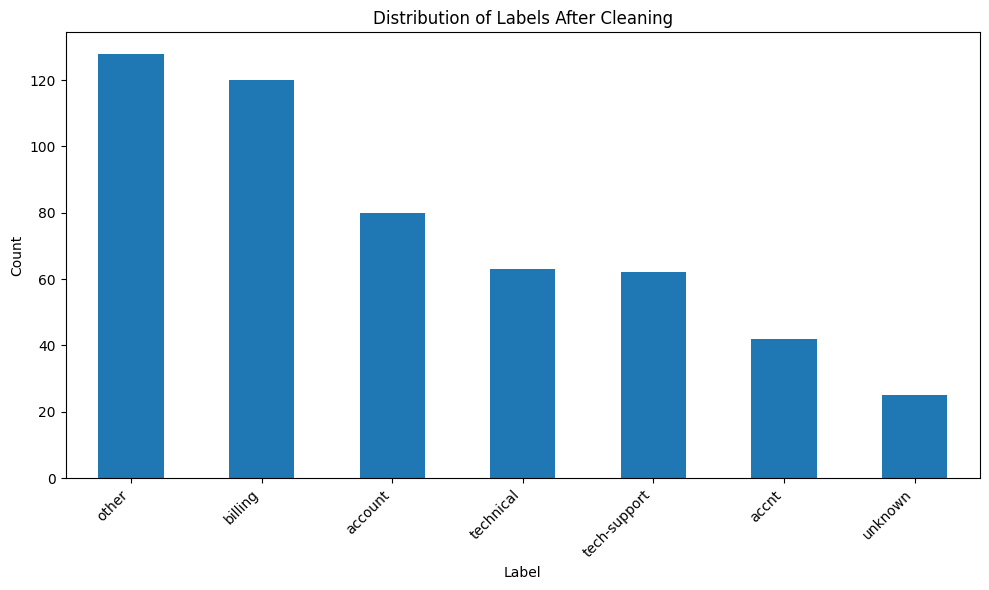


Value counts after cleaning:
label
other           128
billing         120
account          80
technical        63
tech-support     62
accnt            42
unknown          25
Name: count, dtype: int64


In [75]:
# Analyze the distribution of labels after cleaning
label_counts = df['label'].value_counts()

plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Distribution of Labels After Cleaning')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nValue counts after cleaning:")
print(label_counts)

In [78]:
# Save cleaned dataset
df.to_csv("customer_support_tickets_cleaned.csv", index=False)


In [79]:
# Rechecking for missing data

print("Columns:", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

Columns: ['text', 'label', 'ticket_id', 'agent_name']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        520 non-null    object
 1   label       520 non-null    object
 2   ticket_id   520 non-null    int64 
 3   agent_name  520 non-null    object
dtypes: int64(1), object(3)
memory usage: 16.4+ KB
None

Missing values per column:
text          0
label         0
ticket_id     0
agent_name    0
dtype: int64
